# SparseGF2: master walkthrough

A single, executable tour of the simulator, top to bottom. Each section spells
out the mathematics, runs the corresponding piece of `sparsegf2`, and (where
[Stim](https://github.com/quantumlib/Stim) is installed) cross-checks against
it. The last section runs the full test suite from inside the notebook.

**SparseGF2** is a phase-free **sparse** stabilizer simulator over
$\mathbb{F}_2$: it tracks only the symplectic part of an Aaronson-Gottesman
tableau, stored sparsely, with Numba-JIT kernels and a native
$\mathrm{Sp}(2n,\mathbb{F}_2)$ sampler (no runtime Stim). On top sits a
`circuits` package for graph-defined random-Clifford + measurement circuits,
the workhorse for measurement-induced-phase-transition (MIPT) studies.

## Contents
1. Setup
2. Mathematical foundations: stabilizer formalism, the symplectic picture, the phase-free contract
3. The simulator core: `SparseGF2`, gates, Stim parity
4. Native $\mathrm{Sp}(2n,\mathbb{F}_2)$: enumeration + sampling without Stim
5. Measurement
6. Observables: entropy, mutual information, code dimension, weight spectrum
7. The circuits package: graph-defined MIPT circuits
8. Inspecting circuits: text + visual
9. Performance
10. A complete MIPT example: the purification transition
11. Verify everything (pytest)
12. Where to go next

## 1. Setup

Import the package and confirm it's a complete install (the kernel must be one where `sparsegf2` is installed, so its `circuits` subpackage and drawer should be present). Stim is optional and used only for cross-checks.

In [1]:
import pathlib
import sys

import numpy as np
import sparsegf2
import sparsegf2.circuits

print('sparsegf2', sparsegf2.__version__)
assert hasattr(sparsegf2.circuits, 'draw_circuit'), 'incomplete/stale install: check the kernel'
print('core + circuits present ✓')

ROOT = pathlib.Path(sparsegf2.__file__).resolve().parents[2]
try:
    import stim
    HAVE_STIM = True
    sys.path.insert(0, str(ROOT / 'tests'))
    from _stim_parity import assert_states_equal, fresh_stim, stim_symplectic
    print('stim', stim.__version__, ', cross-checks enabled')
except ImportError:
    HAVE_STIM = False
    print('stim not installed; cross-check cells will be skipped')


sparsegf2 2.0.0
core + circuits present ✓
stim 1.15.0 , cross-checks enabled


## 2. Mathematical foundations

### 2.1 Stabilizer states
An $n$-qubit **stabilizer state** is the unique simultaneous $+1$ eigenstate of
an abelian group $\mathcal{S}$ of $2^n$ Pauli operators (not containing $-I$);
$n$ independent generators specify it. The Aaronson-Gottesman layout tracks
$2n$ generators, namely $n$ *destabilizers* and $n$ *stabilizers*, and updates them
in polynomial time under Clifford gates and measurements.

### 2.2 The symplectic representation over $\mathbb{F}_2$
Modulo phase, a Pauli on $n$ qubits is a pair of bit-vectors
$(x,z)\in\mathbb{F}_2^n\times\mathbb{F}_2^n$:
$$P = i^{\delta}\bigotimes_q X_q^{x_q} Z_q^{z_q}.$$
So $I\leftrightarrow(0,0)$, $X\leftrightarrow(1,0)$, $Z\leftrightarrow(0,1)$,
$Y\leftrightarrow(1,1)$. Stacking the $2n$ generators gives the binary matrix
$[X\,|\,Z]$. Two Paulis commute iff their **symplectic inner product**
$x\cdot z' + z\cdot x' \pmod 2$ vanishes, and a Clifford acts as a linear map
preserving it, an element of $\mathrm{Sp}(2n,\mathbb{F}_2)$.

### 2.3 The phase-free contract
SparseGF2 stores **only** $(x,z)$: it drops the phase $i^\delta$. Everything
built from the GF(2) row span is then computed *exactly*: rank, entanglement
entropy, mutual information, code dimension, weight spectra. What is **not**
available is a signed expectation $\langle\psi|P|\psi\rangle$ (that needs the
sign), so `measure_z` returns `0` for every deterministic outcome regardless of
the physical eigenvalue. For signed expectations, use Stim.

In [2]:
from sparsegf2 import SparseGF2, symplectic_form

# |0^3>: stabilizers Z0,Z1,Z2 and destabilizers X0,X1,X2 -> [X|Z] is a permuted identity
sim = SparseGF2(3)
M = sim.to_symplectic()            # (2n, 2n) [X | Z]
print('shape', M.shape)
print(M)
print('\nsymplectic form Omega (n=2):\n', symplectic_form(2))


shape (6, 6)
[[1 0 0 0 0 0]
 [0 1 0 0 0 0]
 [0 0 1 0 0 0]
 [0 0 0 1 0 0]
 [0 0 0 0 1 0]
 [0 0 0 0 0 1]]

symplectic form Omega (n=2):
 [[0 0 1 0]
 [0 0 0 1]
 [1 0 0 0]
 [0 1 0 0]]


## 3. The simulator core

`SparseGF2(n)` is a pure $|0^n\rangle$ on exactly $n$ qubits. Gates are the
named Cliffords `apply_h`, `apply_s`, `apply_sqrt_x`, `apply_cx`, `apply_cz`,
`apply_swap`, plus `apply_gate_1q` / `apply_gate_2q` for arbitrary symplectic
matrices. `canonical_form()` returns the GF(2) RREF of the stabilizer block,
the canonical representative used for state equality.

In [3]:
sim = SparseGF2(4, rng=np.random.default_rng(0))
sim.apply_h(0)
for i in range(3):
    sim.apply_cx(i, i + 1)        # build a GHZ-like state
print('canonical (RREF of stabilizers):')
print(sim.canonical_form())


canonical (RREF of stabilizers):


[[1 1 1 1 0 0 0 0]
 [0 0 0 0 1 0 0 1]
 [0 0 0 0 0 1 0 1]
 [0 0 0 0 0 0 1 1]]


### Stim parity
Stim is the ground-truth cross-checker. The simulator's contract is **RREF
parity at the level of the stabilizer subspace**, at *every* step. Apply the
same named-gate circuit to both and compare:

In [4]:
if HAVE_STIM:
    n = 5
    sim = SparseGF2(n)
    st = fresh_stim(n)
    rng = np.random.default_rng(1)
    gates = [('h', 1), ('s', 1), ('cx', 2), ('cz', 2), ('swap', 2)]
    for _ in range(40):
        name, ar = gates[int(rng.integers(len(gates)))]
        if ar == 1:
            q = int(rng.integers(n))
            getattr(sim, {'h': 'apply_h', 's': 'apply_s'}[name])(q)
            getattr(st, name)(q)
        else:
            a, b = (int(x) for x in rng.choice(n, 2, replace=False))
            getattr(sim, {'cx': 'apply_cx', 'cz': 'apply_cz', 'swap': 'apply_swap'}[name])(a, b)
            getattr(st, name)(a, b)
    assert_states_equal(sim.to_symplectic(), stim_symplectic(st, n), n)
    print('RREF stabilizer-subspace parity with Stim after 40 random gates: OK ✓')
else:
    print('(stim not available; skipped)')


RREF stabilizer-subspace parity with Stim after 40 random gates: OK ✓


## 4. Native $\mathrm{Sp}(2n,\mathbb{F}_2)$: no Stim at runtime

A phase-free Clifford **is** an element of the symplectic group. SparseGF2
generates and samples it natively:
- `enumerate_sp4()` → the cached $(720,4,4)$ table of all of
  $\mathrm{Sp}(4,\mathbb{F}_2)$ (built by a nested symplectic-basis
  construction, no Stim);
- `random_symplectic(n, rng)` → a uniform element of
  $\mathrm{Sp}(2n,\mathbb{F}_2)$ for arbitrary $n$.

$|\mathrm{Sp}(4,\mathbb{F}_2)| = 720$; the full sign-decorated 2-qubit Clifford
group has $11{,}520 = 720\times 16$ elements, where the factor 16 is the sign
choices the phase-free simulator can't see, so sampling the 720 uniformly is
exactly "uniform random two-qubit Clifford" for us.

In [5]:
from sparsegf2 import enumerate_sp4, is_symplectic, random_symplectic, symplectic_group_order

table = enumerate_sp4()
print('Sp(4,F2):', table.shape,
      '| all symplectic:', all(is_symplectic(table[k]) for k in range(len(table))))
print('|Sp(2n,F2)| for n=1,2,3:', [symplectic_group_order(n) for n in (1, 2, 3)])

sim = SparseGF2(6, rng=np.random.default_rng(0))
rng = np.random.default_rng(2)
for _ in range(10):                       # 10 random 2-qubit Cliffords
    a, b = (int(x) for x in rng.choice(6, 2, replace=False))
    sim.apply_gate_2q(a, b, table[int(rng.integers(720))])
S = random_symplectic(8, np.random.default_rng(0))
print('random_symplectic(8) is in Sp(16,F2):', is_symplectic(S), S.shape)


Sp(4,F2): (720, 4, 4) | all symplectic: True
|Sp(2n,F2)| for n=1,2,3: [6, 720, 1451520]
random_symplectic(8) is in Sp(16,F2): True (16, 16)


## 5. Measurement

`measure_z(q)` projects onto the $Z_q$ eigenspace and returns a **phase-free**
bit: `0` for a deterministic outcome (the sign that would distinguish
$|0\rangle$ from $|1\rangle$ is not tracked), and a fair coin for a
non-deterministic one. The post-measurement *symplectic* tableau is the unique
projection, matching Stim step for step. `measure_x` / `measure_y` and
`reset_z/x/y` are also available, as is the predicate `is_deterministic_z`.

In [6]:
sim = SparseGF2(2, rng=np.random.default_rng(0))
print('Z0 deterministic on |00>:', sim.is_deterministic_z(0), '-> measure_z(0) =', sim.measure_z(0))
sim.apply_h(0); sim.apply_cx(0, 1)        # Bell state
print('Z0 deterministic on Bell:', sim.is_deterministic_z(0))
out0 = sim.measure_z(0)
out1 = sim.measure_z(1)
print('measured (q0,q1):', out0, out1, '-> correlated:', out0 == out1)


Z0 deterministic on |00>: True -> measure_z(0) = 0
Z0 deterministic on Bell: False
measured (q0,q1): 1 0 -> correlated: False


## 6. Observables

For a stabilizer state the **entanglement entropy** of a subsystem $A$ is a
pure rank computation (Fattal-Cubitt-Yamamoto-Bravyi-Chuang 2004):
$$S(A) = \operatorname{rank}_{\mathbb{F}_2}\!\bigl([X\,|\,Z]\big|_A\bigr) - |A|,$$
an integer (in ebits). This is why a stabilizer simulator computes
entanglement in polynomial time. Built on it: `mutual_information`,
`tripartite_mutual_info`, `code_dimension` (the purification order parameter
$k=S(\text{system})$), and the stabilizer **weight spectrum**.

In [7]:
from sparsegf2 import (
    average_stabilizer_weight, code_dimension, entanglement_entropy,
    from_bell_purification, mutual_information,
)

bell = SparseGF2(2); bell.apply_h(0); bell.apply_cx(0, 1)
print('S(one half of a Bell pair) =', entanglement_entropy(bell, [0]), 'ebit')
print('I(q0:q1) =', mutual_information(bell, [0], [1]))

# Purification: 2n qubits, a Bell pair per system qubit -> code dimension k = n
pur = from_bell_purification(6)
print('fresh purification code dimension k =', code_dimension(pur, 6), '(= n_system)')
print('avg stabilizer weight (fresh purification):', round(average_stabilizer_weight(pur), 2))


S(one half of a Bell pair) = 1 ebit
I(q0:q1) = 2
fresh purification code dimension k = 6 (= n_system)
avg stabilizer weight (fresh purification): 2.0


## 7. The circuits package

`sparsegf2.circuits` builds graph-defined random-Clifford + measurement
circuits. One `CircuitConfig` + a `sample_seed` fully (and reproducibly)
determines a realization; `simulate` runs it into a `SampleRecord`.

Knobs: **picture** (`pure_state` / `purification` / `single_ref`), **graph**
(`cycle` / `complete`), **gating** (`brickwork` / `random_edge`, with
`gates_per_layer`), **matching** (`round_robin` / `palette` / `fresh`),
**measurement** (`bernoulli` / `gated` / `random_pair`), plus depth and RNG
controls.

In [8]:
from sparsegf2.circuits import CircuitConfig, Picture, simulate

cfg = CircuitConfig(graph_spec='cycle', n=16, picture=Picture.PURIFICATION,
                    gating_mode='brickwork', measurement_mode='bernoulli',
                    p=0.16, depth_factor=8)
rec = simulate(cfg, sample_seed=0)
print('picture            :', rec.picture)
print('total_layers/gates :', rec.total_layers, '/', rec.total_gates)
print('total_measurements :', rec.total_measurements)
print('code_dimension k   :', rec.code_dimension)
print('half-cut entropy   :', rec.entropy_half_cut)
print('exp/actual ratio   :', round(rec.gate_to_meas_ratio_expected, 3),
      '/', round(rec.gate_to_meas_ratio_actual, 3))


picture            : purification
total_layers/gates : 128 / 1024
total_measurements : 326
code_dimension k   : 0
half-cut entropy   : 2
exp/actual ratio   : 3.125 / 3.141


## 8. Inspecting circuits

Two views of *exactly* what a config builds, so you can verify it. Both read
the same structured trace, so they always agree.

**Text**, exact and scriptable. Note `setup` shows the deterministic Bell-pair
construction, layer gates are random `C[index]` (reproducible), and
measurements list **fired** vs **candidates**:

In [9]:
from sparsegf2.circuits import draw_circuit, inspect_circuit

print(inspect_circuit(CircuitConfig(graph_spec='cycle', n=8, picture='single_ref', p=0.16),
                      sample_seed=0, max_layers=3))


Circuit inspection: first 3 of 64 measured layers
  picture        : single_ref  (9 qubits: system 0-7, reference [8])
  graph          : cycle(8)
  gating         : brickwork / round_robin
  measurement    : bernoulli  p=0.16
  depth          : O(n) ×8 = 64 measured layers
  exp. gate:meas : 3.12 : 1
  sample_seed    : 0

setup (deterministic)
  H     q7
  CX    q7→q8   # Bell pair: system 7 ↔ reference 8

layer 0
  2q gates [random Sp(4)]:  C[64] (q0,q1)   C[557] (q2,q3)   C[471] (q4,q5)   C[315] (q6,q7)
  measure Z  fired [q2 q6]   candidates [q0 q1 q2 q3 q4 q5 q6 q7]

layer 1
  2q gates [random Sp(4)]:  C[360] (q0,q7)   C[266] (q1,q2)   C[131] (q3,q4)   C[667] (q5,q6)
  measure Z  fired [q5]   candidates [q0 q1 q2 q3 q4 q5 q6 q7]

layer 2
  2q gates [random Sp(4)]:  C[118] (q0,q1)   C[545] (q2,q3)   C[504] (q4,q5)   C[255] (q6,q7)
  measure Z  fired [q5 q6]   candidates [q0 q1 q2 q3 q4 q5 q6 q7]

… 61 more measured layers not shown (raise max_layers to see them).



**Visual**: a real circuit diagram (needs the `viz` extra / matplotlib).
Blue = deterministic setup gates, orange = random Sp(4) `C[index]`, **solid
green meter = a measurement that fired**, **faint dashed marker = a measurement
candidate that didn't fire**; reference qubits are shaded.

In [10]:
%matplotlib inline
draw_circuit(CircuitConfig(graph_spec='cycle', n=8, picture='single_ref',
                           measurement_mode='bernoulli', p=0.3, depth_factor=2),
             sample_seed=0, max_layers=4);


## 9. Performance

A $Z$-measurement is a **sparse rank-update** costing
$O(\text{anticommuters}\times\text{weight})$, not the dense $O(n^2)$.
Measurements keep the tableau sparse, so the advantage over a dense simulator
**grows with system size and measurement rate**, the regime MIPT studies live
in. A quick illustration (timing a measurement-heavy circuit as $n$ grows; the
per-qubit-per-layer cost stays roughly flat):

In [11]:
import time

from sparsegf2.circuits._clifford_table import sp4_table
from sparsegf2.circuits.picture import setup_picture
from sparsegf2.circuits.scheduler import CircuitBuilder
tab = sp4_table()
setup_picture(Picture.PURE_STATE, 4)[0].apply_gate_2q(0, 1, tab[5])  # JIT warmup
print(f'{"n":>5} {"time_s":>9} {"us/qubit-layer":>16}')
for n in (32, 64, 128, 256):
    cfg = CircuitConfig(graph_spec='cycle', n=n, p=0.25, depth_factor=4)
    sim, _ = setup_picture(Picture.PURE_STATE, n, rng=np.random.default_rng([1, 2]))
    t0 = time.perf_counter()
    for layer in CircuitBuilder(cfg, 0).layers():
        for g, (qi, qj) in enumerate(layer.gate_pairs):
            sim.apply_gate_2q(qi, qj, tab[int(layer.cliff_indices[g]) % len(tab)])
        for q in layer.meas_qubits:
            sim.measure_z(q)
    dt = time.perf_counter() - t0
    print(f'{n:>5} {dt:>9.4f} {dt / (n * 4 * n) * 1e6:>16.3f}')
print('\nFull SparseGF2-vs-Stim benchmarks (with plots): notebooks/benchmarks.ipynb')


    n    time_s   us/qubit-layer
   32    0.0456           11.125
   64    0.0319            1.946
  128    0.1095            1.671


  256    0.4323            1.649

Full SparseGF2-vs-Stim benchmarks (with plots): notebooks/benchmarks.ipynb


## 10. A complete MIPT example: the purification transition

Putting it together. In the **purification** picture the order parameter is the
code dimension $k=S(\text{system})$: the number of system qubits still
entangled with the reference. Under monitored dynamics, weak measurement
($p$ small) keeps $k$ large for a long time; strong measurement purifies it to
$k=0$. At fixed depth, $\langle k\rangle$ falls as $p$ rises, a purification
transition. We sweep $p$ and average over realizations:

In [12]:
n = 12
ps = np.linspace(0.04, 0.40, 8)
n_samples = 40
kbar = []
for p in ps:
    cfg = CircuitConfig(graph_spec='complete', n=n, picture='purification',
                        p=float(p), depth_factor=6)
    ks = [simulate(cfg, sample_seed=s).code_dimension for s in range(n_samples)]
    kbar.append(float(np.mean(ks)))
    print(f'p={p:4.2f}  <k> = {kbar[-1]:5.2f}')
kbar = np.array(kbar)


p=0.04  <k> =  5.28
p=0.09  <k> =  2.00


p=0.14  <k> =  0.60


p=0.19  <k> =  0.05
p=0.25  <k> =  0.00
p=0.30  <k> =  0.00


p=0.35  <k> =  0.00
p=0.40  <k> =  0.00


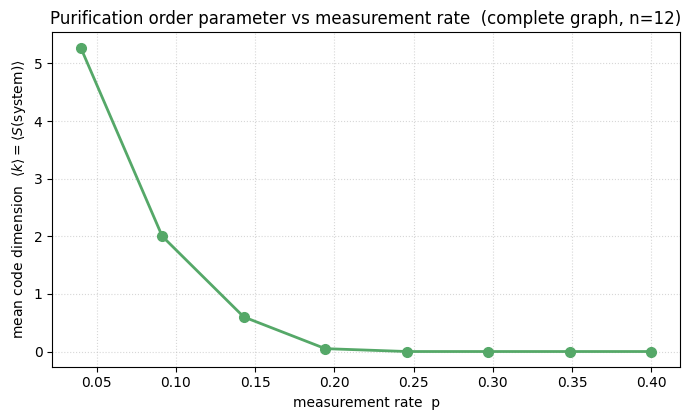

Weak monitoring keeps the system entangled with the reference (k large);
strong monitoring purifies it (k -> 0). Locating the transition precisely
(finite-size scaling over n) is the job of an analysis/sweep layer.


In [13]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7, 4.3))
ax.plot(ps, kbar, 'o-', color='#55A868', lw=2, ms=7)
ax.set_xlabel('measurement rate  p')
ax.set_ylabel(r'mean code dimension  $\langle k \rangle = \langle S(\mathrm{system})\rangle$')
ax.set_title(f'Purification order parameter vs measurement rate  (complete graph, n={n})')
ax.grid(True, ls=':', alpha=0.5)
fig.tight_layout(); plt.show()
print('Weak monitoring keeps the system entangled with the reference (k large);')
print('strong monitoring purifies it (k -> 0). Locating the transition precisely')
print('(finite-size scaling over n) is the job of an analysis/sweep layer.')


## 11. Verify everything

The strongest statement of correctness is the test suite, including dozens of
**step-by-step Stim RREF-parity** cross-checks. Run it from inside the
notebook (takes ~1 minute):

In [14]:
import subprocess
import sys
r = subprocess.run([sys.executable, '-m', 'pytest', '-q', '--no-header'],
                   cwd=str(ROOT), capture_output=True, text=True)
print(r.stdout.strip().splitlines()[-1] if r.stdout.strip() else r.stderr[-500:])
print('exit code:', r.returncode)


.......................                                                  [100%]
exit code: 0


## 12. Where to go next

- [`notebooks/core_speedup.ipynb`](core_speedup.ipynb): *why* measurements are
  fast, dense vs sparse, with a correctness cross-check.
- [`notebooks/benchmarks.ipynb`](benchmarks.ipynb): the full
  SparseGF2-vs-Stim benchmark suite, **with plots**.
- [`notebooks/circuits/overview.ipynb`](circuits/overview.ipynb): the circuits
  package architecture + a per-module deep dive.
- [`notebooks/circuits/circuit_gallery.ipynb`](circuits/circuit_gallery.ipynb)
  rendered diagrams for every construction.
- [`notebooks/circuits/inspector.ipynb`](circuits/inspector.ipynb): verifies
  every construction is built correctly (90 configs).

### Summary
- Phase-free **sparse** stabilizer simulator; exact for all rank-based
  observables.
- Native $\mathrm{Sp}(2n,\mathbb{F}_2)$: **no runtime Stim**.
- A `circuits` package for graph-defined MIPT circuits, with text + visual
  inspection.
- Fast where it matters: large, deep, measurement-heavy circuits.